In this notebook, we will use sklearn's LASSO for feature selection. This serves to simplify our dataset and improve interpretability.

In [87]:
#dependencies
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.optimize import minimize # for ensemble weight optimization
#for feature selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, LassoCV, LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

In [31]:
# download LightGBM package
!pip install lightgbm

In [36]:
# download catboost package
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.8/28.8 MB 27.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 34.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [catboost]3/4 [catboost]


In [38]:
# LGBM & catboost dependencies
import lightgbm as lgbm
from catboost import CatBoostRegressor
#from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV

In [3]:
# function for model evalaution in both log-price 'units' as well as natural units (USD dollar) 
def evaluate_model(y_true, y_pred_log):

    # TRUE VALUES IN LOG SPACE
    y_true_log = np.log1p(y_true)

    # BACK TRANSFORM PREDICTIONS
    y_pred = np.expm1(y_pred_log)

    # --- METRICS IN LOG SPACE ---
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    r2_log = r2_score(y_true_log, y_pred_log)
    mape_log = mean_absolute_percentage_error(y_true_log, y_pred_log)

    # --- METRICS IN PRICE SPACE ---
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    print("------ LOG METRICS ------")
    print("RMSE_log:", rmse_log)
    print("MAE_log:", mae_log)
    print("R2_log:", r2_log)
    print("MAPE_log:", mape_log)

    print("\n------ PRICE METRICS ($) ------")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2:", r2)
    print("MAPE:", mape)

    return

In [4]:
train = pd.read_csv("train.csv")
val = pd.read_csv("val.csv")

#drop unnecessary features
UnneededFeatures = ['sale_date.1', 'maker_name_maker', 'is_ambiguous', 'candidate_count', 'location_filled', 'date', 'usd', 'gbp', 'eur', 'candidate_count']
train = train.drop(columns = UnneededFeatures)
valid = val.drop(columns = UnneededFeatures)

X_train = train.iloc[:, train.columns != 'price_usd_real']
X_valid = valid.iloc[:, train.columns != 'price_usd_real']
Y_train = train.iloc[:, train.columns == 'price_usd_real']
Y_valid = valid.iloc[:, train.columns == 'price_usd_real']


In [6]:
#log transforming target
train['log_price'] = np.log1p(train['price_usd_real'])

#groups each instrument type of the train set by its mean/median price
type_mean = train.groupby('type')['log_price'].mean()  
type_median = train.groupby('type')['log_price'].median()

type_mean.head()

type
Bass          9.835546
Bass Bow      7.830970
Bass Viol    11.087919
Cello        10.124304
Cello Bow     8.540933
Name: log_price, dtype: float64

We will temporarily create two new columns in the validation set to predict the price of each instrument sale using our means/medians above.

In [7]:
#check for missing values
print(X_train['type'].isna().any())
print(X_valid['type'].isna().any())

#creating new columns
valid['type_mean']= valid['type'].map(type_mean)
valid['type_median'] = valid['type'].map(type_median)
valid.head()

False
False


,sale_date,maker_id,maker_name,type,city_maker,auction_house,lot,bold_currency,Year,Month,...,MCI,real_price_gold,country_iso1,admin1_name,admin2_name,role,maker_last_name,birth_cent,type_mean,type_median
0,2000-02-14,2827,"Collin-Mézin, Charles Jean-Baptiste III",Violin,Paris,Phillip's,25,gbp,2000,2,...,-6.037718,588.0587,FR,Île-de-France,Paris,Violin maker,Collin-Mézin,20.0,9.159512,8.991187
1,1995-11-14,356,"Thibouville-Lamy, Jérôme Firm",Violin,Mirecourt,Bonhams,309,gbp,1995,11,...,4.018622,815.9887,FR,Grand Est,Vosges,Bow maker / Violin maker,Thibouville-Lamy,19.0,9.159512,8.991187
2,2008-10-07,185,"Gadda, Mario",Cello,Mantua,Sotheby's,136,gbp,2008,10,...,-4.978523,1331.5068,IT,Lombardy,Provincia di Mantova,Violin maker,Gadda,20.0,10.124304,10.062779
3,1993-05-23,1327,"Huber, Johann Georg",Viola,Vienna,Skinner,164,usd,1993,5,...,1.206404,851.0234,AT,Vienna,Wien Stadt,Violin maker,Huber,18.0,9.097133,9.065886
4,2010-10-10,524,"Pedrazzini, Giuseppe",Violin,Cremona,Skinner,-,usd,2010,10,...,3.251219,2002.1250,IT,Lombardy,Provincia di Cremona,Violin maker,Pedrazzini,19.0,9.159512,8.991187


# Model 0: Mean & Median Baseline Models

In [ ]:
#evaluating base model
print("Base model: Predicting prices by mean and median of train set \n")
print("Mean")
evaluate_model(Y_valid, valid['type_mean'])

print("\n Median")
evaluate_model(Y_valid, valid['type_median'])

Base model: Predicting prices by mean and median of train set 

Mean
------ LOG METRICS ------
RMSE_log: 1.285456313665743
MAE_log: 0.988432919402884
R2_log: 0.10001861657415356
MAPE_log: 0.11279419733674426

------ PRICE METRICS ($) ------
RMSE: 125935.18437162781
MAE: 22152.072084267635
R2: -0.014001477146394548
MAPE: 1.5594670219204665

 Median
------ LOG METRICS ------
RMSE_log: 1.2931641897639936
MAE_log: 0.9841738236638584
R2_log: 0.0891932891990842
MAPE_log: 0.11087921033874927

------ PRICE METRICS ($) ------
RMSE: 126116.55690583902
MAE: 22118.01709392209
R2: -0.016924321211996718
MAPE: 1.3814586533054676


It is clear that predicting fine string instrument prices based on their instrument type alone is really unsuccessful because there are so many charactersitics/features that are not accounted for in this way, such as the maker who plays a hige role for the price, the instrument age, its condition, provenence and many more factors.

In [9]:
#dropping columns we created for base model
valid = valid.drop(columns = ['type_mean', 'type_median'])
train = train.drop(columns = ['log_price'])

In [10]:
#collect categorical features
CategoricalCols = train.select_dtypes(include=["object", "bool"]).columns.tolist()

for x in CategoricalCols:
    print(f"{x} has {train[x].nunique()} unique values")

sale_date has 941 unique values
maker_name has 3060 unique values
type has 14 unique values
city_maker has 628 unique values
auction_house has 27 unique values
lot has 1244 unique values
bold_currency has 3 unique values
country_iso1 has 37 unique values
admin1_name has 164 unique values
admin2_name has 371 unique values
role has 34 unique values
maker_last_name has 2164 unique values


We will consider features with less that 20 unique values as "low cardinality", and the rest as "high cardinality".

In [11]:
LowCardCols = ["type", "bold_currency"]
HighCardCols = ["sale_date", "maker_name", "city_maker", "auction_house", "lot", "country_iso1", "admin1_name", "admin2_name", "role", "maker_last_name"]

In [12]:
#log transforming economic features
LogColumns = ['real_price_gold', 'SP500_real']

In [13]:
#features with numerical values
numberdtype = X_train.select_dtypes(include=[np.number]).columns.tolist()

#prevent overlap
NumericalCols = list( set(numberdtype) - set(LogColumns))


In [14]:
#impute with median and scale numerical columns
Numerical_transformer = Pipeline([
     ('imputer', SimpleImputer(strategy='median')), 
     ('scaler', StandardScaler() )
     ])

#impute and one hot encode low cardinality columns
OneHot_transformer = Pipeline([
('imputer', SimpleImputer(strategy='constant', fill_value="other" )),
('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

#impute and target encode high cardinality columns
Target_transformer = Pipeline([
('imputer', SimpleImputer(strategy='constant', fill_value="other")),
('target', TargetEncoder() )
])

#transform "log columns"
log_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p, feature_names_out="one-to-one") ),
    ('scale', StandardScaler())
])



In [ ]:
#this will apply our transformations
preprocessor = ColumnTransformer(
    transformers =[
        ('lognum', log_transformer, LogColumns),
        ('lowcard', OneHot_transformer, LowCardCols ),
        ('highcard', Target_transformer, HighCardCols ) ,
        ('num', Numerical_transformer, NumericalCols )],
        remainder = 'passthrough',
        sparse_threshold=0
)

# Model 1: Lasso-Regression

We can fit our data to a lasso regression pipeline with the same transformed columns. We can use this with the goal of feature selection and determining feature importance.

In [16]:
#lassocv with 10 cross validation folds
pipeline_lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('lasso', LassoCV(cv=10))
])


lr = pipeline_lasso.fit(X_train,np.log1p(Y_train))



/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [60]:
#predictions in log prices
lasso_pred = lr.predict(X_valid)

print("Lassocv model evaluation: \n")
evaluate_model(Y_valid, lasso_pred)


#gives the optimal penalty determined by lassocv
optimal_alpha = pipeline_lasso.named_steps['lasso'].alpha_
print("\nOptimal alpha:", f"{optimal_alpha:.5f}")


Lassocv model evaluation: 

------ LOG METRICS ------
RMSE_log: 0.6584080815567188
MAE_log: 0.5017359614433081
R2_log: 0.7638928231164228
MAPE_log: 0.058211365794207125

------ PRICE METRICS ($) ------
RMSE: 99207.44820468583
MAE: 13996.372828001075
R2: 0.37073586339306774
MAPE: 0.6492848284193581

Optimal alpha: 0.00125


In [18]:
#recovers the features transformed in the pipeline
preprocessor_lasso = pipeline_lasso.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()

In [19]:
#gives coefficients used for each feature in regression
lasso_step = lr.named_steps['lasso']
coefficients = lasso_step.coef_

zerofeatures = []
nonzerofeatures = []

#setting a lower bound for a coefficient to be considered "nonzero"
epsilon = 1e-5

for i in range(len(feature_names)):
    if abs(coefficients[i]) < epsilon:
        zerofeatures.append(feature_names[i])
    else: nonzerofeatures.append(feature_names[i])

#the features with a coefficient of zero
for x in zerofeatures:
    print(x)


lowcard__type_Bass
lowcard__type_Bass Bow
lowcard__type_Bass Viol
lowcard__type_Miscellaneous
lowcard__type_Tenor Viol
lowcard__type_Treble Viol
lowcard__type_Viola Bow
lowcard__type_Viola d'Amore
lowcard__bold_currency_usd
num__gbp_usd_x
num__SP500_trend_ratio
num__SP500_30d_ret
num__SP500_ma200
num__10y_yield_90d_change
num__cpi_usd
num__SP500_vol_30d
num__Year


In [25]:
# feature and corresponding coefficient
lasso_coeffs = pd.DataFrame(index=feature_names, columns=['Lasso_Coeffs'])
lasso_coeffs.Lasso_Coeffs = coefficients
lasso_coeffs.loc[nonzerofeatures, :]

,Lasso_Coeffs
lognum__real_price_gold,-0.019520
lognum__SP500_real,0.012494
lowcard__type_Cello,0.808961
lowcard__type_Cello Bow,-0.038867
lowcard__type_Small Violin,-0.264283
lowcard__type_Viola,0.058398
lowcard__type_Violin,0.018903
lowcard__type_Violin Bow,-0.140926
lowcard__bold_currency_eur,-0.008924
lowcard__bold_currency_gbp,0.023319


In [66]:
#shows the different alphas selected by lassocv
alphas =lasso_step.alphas_
print(alphas)


[1.2512376  1.16690837 1.08826265 1.01491739 0.94651536 0.88272339
 0.82323079 0.76774779 0.71600416 0.66774787 0.6227439  0.58077305
 0.54163089 0.50512678 0.47108292 0.43933351 0.4097239  0.38210988
 0.35635696 0.33233969 0.30994111 0.28905211 0.26957097 0.25140279
 0.23445908 0.21865732 0.20392055 0.19017699 0.1773597  0.16540625
 0.15425842 0.14386192 0.13416611 0.12512376 0.11669084 0.10882627
 0.10149174 0.09465154 0.08827234 0.08232308 0.07677478 0.07160042
 0.06677479 0.06227439 0.0580773  0.05416309 0.05051268 0.04710829
 0.04393335 0.04097239 0.03821099 0.0356357  0.03323397 0.03099411
 0.02890521 0.0269571  0.02514028 0.02344591 0.02186573 0.02039206
 0.0190177  0.01773597 0.01654062 0.01542584 0.01438619 0.01341661
 0.01251238 0.01166908 0.01088263 0.01014917 0.00946515 0.00882723
 0.00823231 0.00767748 0.00716004 0.00667748 0.00622744 0.00580773
 0.00541631 0.00505127 0.00471083 0.00439334 0.00409724 0.0038211
 0.00356357 0.0033234  0.00309941 0.00289052 0.00269571 0.00251

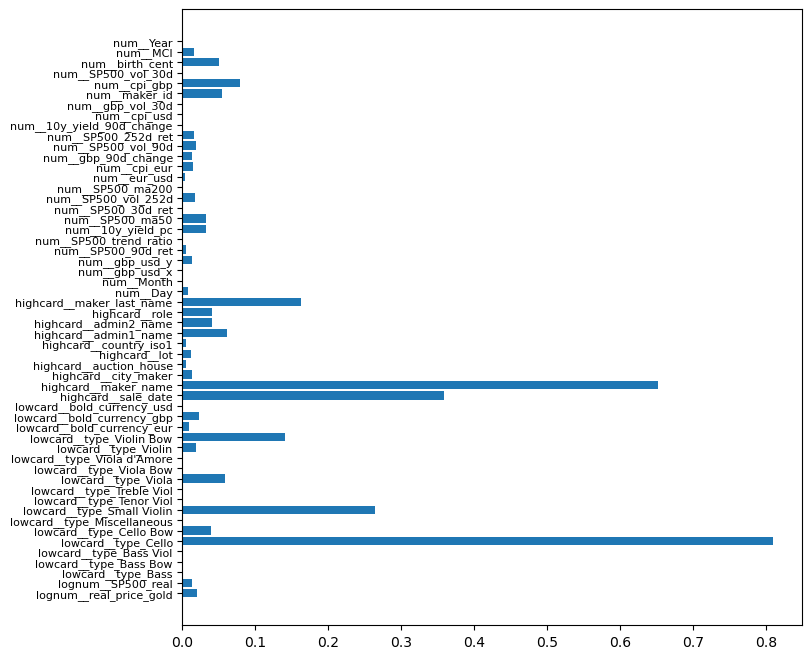

In [33]:
plt.figure(figsize=(8,8))

abs_coefficients = [abs(x) for x in coefficients]
plt.barh(feature_names, abs_coefficients)
plt.tight_layout
plt.yticks(fontsize=8)
plt.show()

Here we see that many different features all carry predictive power: the instrument type is especially crucial for price prediction bt so is the instrument maker. In addition to that the enhanced features that were created especially for this data set seem to have good predictive power. Those are the economic features based, e.g., on the stock market indices, as well as the geographical information inferred for each instrument.

# Model 2: Random Forest

In [34]:
#creates a pipeline object
pipeline_randomforest = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestRegressor(n_estimators=200, random_state=0))
])
#fits our data to the pipeline/model with log transformed target
rf = pipeline_randomforest.fit(X_train,np.log1p(Y_train))

forest_pred = rf.predict(X_valid)

evaluate_model(Y_valid, forest_pred)

/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


------ LOG METRICS ------
RMSE_log: 0.6196200979440363
MAE_log: 0.4688970914758409
R2_log: 0.790892372488958
MAPE_log: 0.054501830673927845

------ PRICE METRICS ($) ------
RMSE: 78097.34782190331
MAE: 11984.435498331128
R2: 0.6100427544769286
MAPE: 0.5932901303842286


# Model 3: LightGBM

Define the Model with default parameters.

In [57]:
lgbm_model = lgbm.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose = -1
)

In [58]:
pipeline_lgbm = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lgbm_model)])

Use cross-validation to find the best model via a grid-search.

In [63]:
'''param_grid = {
    "model__num_leaves": [80, 100, 120, 140],
    "model__learning_rate": [0.005, 0.007, 0.009],
    "model__n_estimators": [800, 900, 1000],
    "model__max_depth": [-1]
}'''
# this parameter grid has already been narrowed down in many iterations of running the algo
param_grid = {
    "model__num_leaves": [62, 63, 64], # best 63
    "model__learning_rate": [0.01, 0.011], # best 0.011
    "model__n_estimators": [2300, 2500, 2700, 2900], # best 2300
    "model__max_depth": [-1]
}


search_lgbm = RandomizedSearchCV(
    pipeline_lgbm,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_iter=20,
    n_jobs=-1,
    verbose=1
)

In [64]:
search_lgbm.fit(X_train, np.log1p(Y_train.values.ravel()))

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13

,estimator,Pipeline(step...verbose=-1))])
,param_distributions,"{'model__learning_rate': [0.008, 0.009, ...], 'model__max_depth': [-1], 'model__n_estimators': [2300, 2500, ...], 'model__num_leaves': [62, 63, ...]}"
,n_iter,20
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [65]:
best_lgbm = search_lgbm.best_estimator_
print(search_lgbm.best_params_)

{'model__num_leaves': 63, 'model__n_estimators': 2300, 'model__max_depth': -1, 'model__learning_rate': 0.011}


### Prediction

In [66]:
y_pred_log_lgbm = best_lgbm.predict(X_valid)
#y_pred_lgbm = np.expm1(y_pred_log_lgbm)

/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [67]:
evaluate_model(Y_valid, y_pred_log_lgbm)

------ LOG METRICS ------
RMSE_log: 0.5915523073845861
MAE_log: 0.44952667337148716
R2_log: 0.8094077715696875
MAPE_log: 0.05224199163204214

------ PRICE METRICS ($) ------
RMSE: 79760.08948291995
MAE: 11785.950275118308
R2: 0.5932611203050077
MAPE: 0.5660110600022191


In [ ]:
# 

# Model 4: CatBoost

In [49]:
y_train_log = np.log1p(Y_train.squeeze())
y_valid_log = np.log1p(Y_valid.squeeze())

cat_model = CatBoostRegressor(
    loss_function='RMSE',
    random_seed=42,
    verbose=0)

pipeline_cat = Pipeline([("preprocessor", preprocessor), ("model", cat_model)])

'''param_dist = {
    "model__iterations": [2000,3000,4000], #best was 2000
    "model__learning_rate": [0.01,0.02,0.03], #best was 0.03
    "model__depth": [10, 12, 15], #best was 10
    "model__l2_leaf_reg": [20], #best was 20
    "model__min_data_in_leaf": [5], #best was 5
}'''
param_dist = {
    "model__iterations": [2000], #best was 2000
    "model__learning_rate": [0.03], #best was 0.03
    "model__depth": [10], #best was 10
    "model__l2_leaf_reg": [20], #best was 20
    "model__min_data_in_leaf": [5], #best was 5
}

search_cat = RandomizedSearchCV(
    pipeline_cat,
    param_distributions=param_dist,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_iter=20,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

In [50]:
search_cat.fit(X_train, y_train_log)

best_cat = search_cat.best_estimator_
print("Best CatBoost params:", search_cat.best_params_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=20. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best CatBoost params: {'model__min_data_in_leaf': 5, 'model__learning_rate': 0.03, 'model__l2_leaf_reg': 20, 'model__iterations': 2000, 'model__depth': 10}


In [51]:
y_pred_log_cat = best_cat.predict(X_valid)

evaluate_model(Y_valid.squeeze(), y_pred_log_cat)

------ LOG METRICS ------
RMSE_log: 0.5905759283339266
MAE_log: 0.44837313222093783
R2_log: 0.8100364114458073
MAPE_log: 0.05210475056832776

------ PRICE METRICS ($) ------
RMSE: 86252.88156355235
MAE: 11872.476555485136
R2: 0.5243454569859778
MAPE: 0.5597352579985887


# Model(s) 5: Ensemble Method
In this section we will combine (in various ways) the predictions of the three performant model (Random Forest, LGBM, CatBoost) in order to determine whether a combination of the models performs better than each one alone.

In [69]:
# stack all the predictions that ought be used in the ensemble
X_ensemble = np.column_stack([
    forest_pred,
    y_pred_log_lgbm,
    y_pred_log_cat
])

## Naive Ensemble

In [70]:
y_pred_avg = X_ensemble.mean(axis=1)

In [72]:
evaluate_model(Y_valid, y_pred_avg)

------ LOG METRICS ------
RMSE_log: 0.5920603811129262
MAE_log: 0.4490121663130108
R2_log: 0.80908023844111
MAPE_log: 0.05219993326280891

------ PRICE METRICS ($) ------
RMSE: 81162.83645121651
MAE: 11701.314874263773
R2: 0.5788286164501342
MAPE: 0.5631582579887113


## Weighted Ensemble
We find the optimal ensemble weights via optimization with a RMSE loss for weighting the models linearly, which is implemented through an additional Ridge Regression. This means the ensemble prediction is a omptimized linear combination of the 3 input model predictions. 

In [73]:
def rmse_loss(weights):
    weights = weights / weights.sum()  # normalize weights, such that they sum to 1
    y_pred = np.dot(X_ensemble, weights)
    return np.sqrt(mean_squared_error(y_valid_log, y_pred))

# initial equal weights
init_weights = np.array([1/3, 1/3, 1/3])

# constraint: weights sum to 1
constraints = {'type': 'eq', 'fun': lambda w: w.sum() - 1}

# bounds: weights between 0 and 1
bounds = [(0, 1)] * 3

result = minimize(rmse_loss, init_weights, bounds=bounds, constraints=constraints) # scipy numerical optimizer

optimal_weights = result.x / result.x.sum()
print("Optimal weights:", optimal_weights)

Optimal weights: [0.        0.4866936 0.5133064]


In [90]:
meta_model = Ridge(alpha=1)
meta_model.fit(X_ensemble, y_valid_log)

y_pred_stacked = meta_model.predict(X_ensemble)

print("Stacking coefficients:", meta_model.coef_)

Stacking coefficients: [-0.00881622  0.45588906  0.56591219]


In [91]:
evaluate_model(Y_valid, y_pred_stacked)

------ LOG METRICS ------
RMSE_log: 0.5879901174371883
MAE_log: 0.4460433732295467
R2_log: 0.8116962642206067
MAPE_log: 0.051848466549446595

------ PRICE METRICS ($) ------
RMSE: 81476.44131411426
MAE: 11661.948581451665
R2: 0.5755676025612575
MAPE: 0.5604766606006077
